# CMRI L02 — Fourier Image Reconstruction Basics

**Computational MRI** · based on a lecture by Ricardo Otazo

This notebook builds the whole reconstruction pipeline on synthetic data, in the order the lecture introduces it:

1. The Fourier transform as a *spectrum* (1D audio example)
2. The Fourier "alphabet" — impulse, rect↔sinc, comb↔comb, triangle↔sinc²
3. 2D FT and **k-space**; reconstruction with the *fftshift dance*
4. Low vs high spatial frequencies (contrast vs edges)
5. k-space cropping → **resolution** (the 64/128/256 demo)
6. Sampling & **aliasing** (Nyquist) → wrap-around
7. **Exercises** (from the exercise sheet): ifft recon, **PSF**, **Hamming vs rectangle / Gibbs**, **oversampling**
8. Zero-padding (Fourier interpolation)
9. **SNR ∝ V·√T**

> Run it cell-by-cell. Then *modify* it: change `N`, the window, the undersampling factor, the noise level. Breaking it and fixing it is where the learning happens.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

np.random.seed(0)
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['image.cmap'] = 'gray'

# ---- The two transforms we use everywhere -------------------------------
# Centered, *unitary* (Parseval-preserving) 2D Fourier pair.
# This is exactly the lecture's 'fftshift dance' (slides 28-29).
def fft2c(img):
    "image -> centered k-space"
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img))) / np.sqrt(img.size)

def ifft2c(ksp):
    "centered k-space -> image"
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(ksp))) * np.sqrt(ksp.size)

def kshow(ksp):
    "display |k-space| on a log scale"
    return np.log(1 + np.abs(ksp))

print("Helpers ready. fft2c / ifft2c are unitary:")
_t = np.random.randn(8, 8) + 1j*np.random.randn(8, 8)
print("  energy(image) =", round(np.sum(np.abs(_t)**2), 6))
print("  energy(kspace) =", round(np.sum(np.abs(fft2c(_t))**2), 6), " (Parseval: should match)")

Helpers ready. fft2c / ifft2c are unitary:
  energy(image) = 140.506176
  energy(kspace) = 140.506176  (Parseval: should match)


## 1. The Fourier transform is a *spectrum*

A pure tone (A4 = 440 Hz, a tuning fork) is a single sinusoid → **one peak**.
A flute playing the same note is periodic but not sinusoidal → a **fundamental + harmonics**.
Same pitch, different *timbre* = different high-frequency content (lecture slide 5).

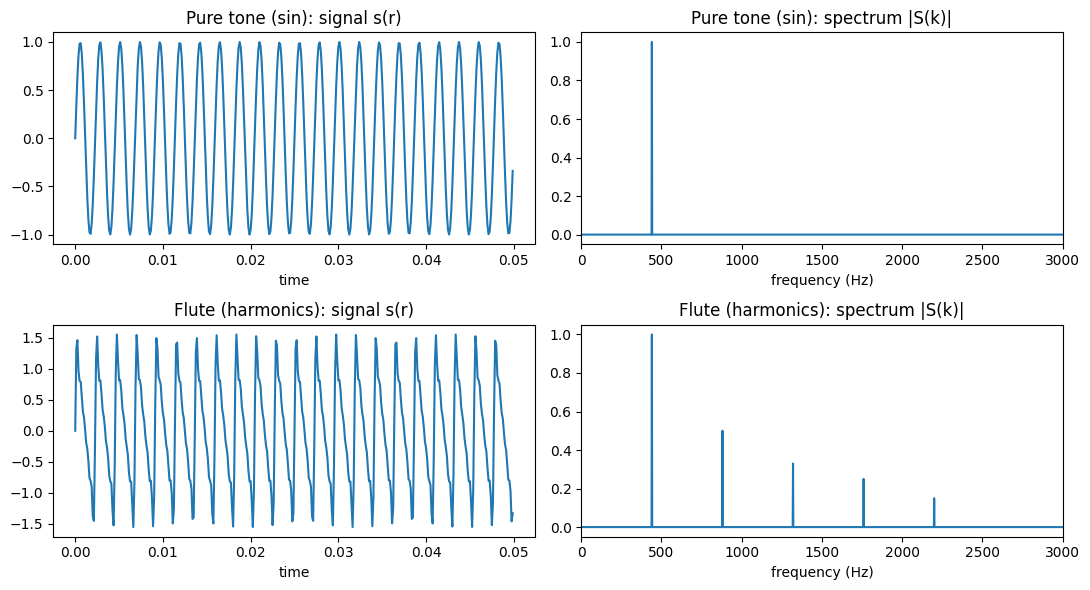

Pure tone -> single peak at 440 Hz. Flute -> peaks at 440, 880, 1320, ... Hz.


In [11]:
fs = 8000          # sampling rate (Hz)
T  = 0.5           # seconds
t  = np.arange(0, T, 1/fs)
f0 = 440.0         # A4

# Pure tone
pure = np.sin(2*np.pi*f0*t)

# 'Flute': fundamental + decaying harmonics
harmonics = [1, 2, 3, 4, 5]
amps      = [1.0, 0.5, 0.33, 0.25, 0.15]
flute = sum(a*np.sin(2*np.pi*h*f0*t) for h, a in zip(harmonics, amps))

def spectrum(x):
    X = np.abs(np.fft.rfft(x))
    fr = np.fft.rfftfreq(len(x), 1/fs)
    return fr, X/X.max()

fig, ax = plt.subplots(2, 2, figsize=(11, 6))
for row, (sig, name) in enumerate([(pure, "Pure tone (sin)"), (flute, "Flute (harmonics)")]):
    ax[row,0].plot(t[:400], sig[:400]); ax[row,0].set_title(f"{name}: signal s(r)")
    ax[row,0].set_xlabel("time"); 
    fr, X = spectrum(sig)
    ax[row,1].plot(fr, X); ax[row,1].set_xlim(0, 3000)
    ax[row,1].set_title(f"{name}: spectrum |S(k)|"); ax[row,1].set_xlabel("frequency (Hz)")
plt.tight_layout(); plt.show()
print("Pure tone -> single peak at 440 Hz. Flute -> peaks at 440, 880, 1320, ... Hz.")

## 2. The Fourier 'alphabet'

Every k-space effect later in the notebook is one of these pairs in disguise.
- impulse ↔ constant
- rectangle ↔ **sinc**
- comb ↔ comb (period `T` ↔ `1/T`) — the basis of **sampling**
- triangle ↔ **sinc²** (triangle = rect ∗ rect, so by the convolution theorem its FT is sinc·sinc)

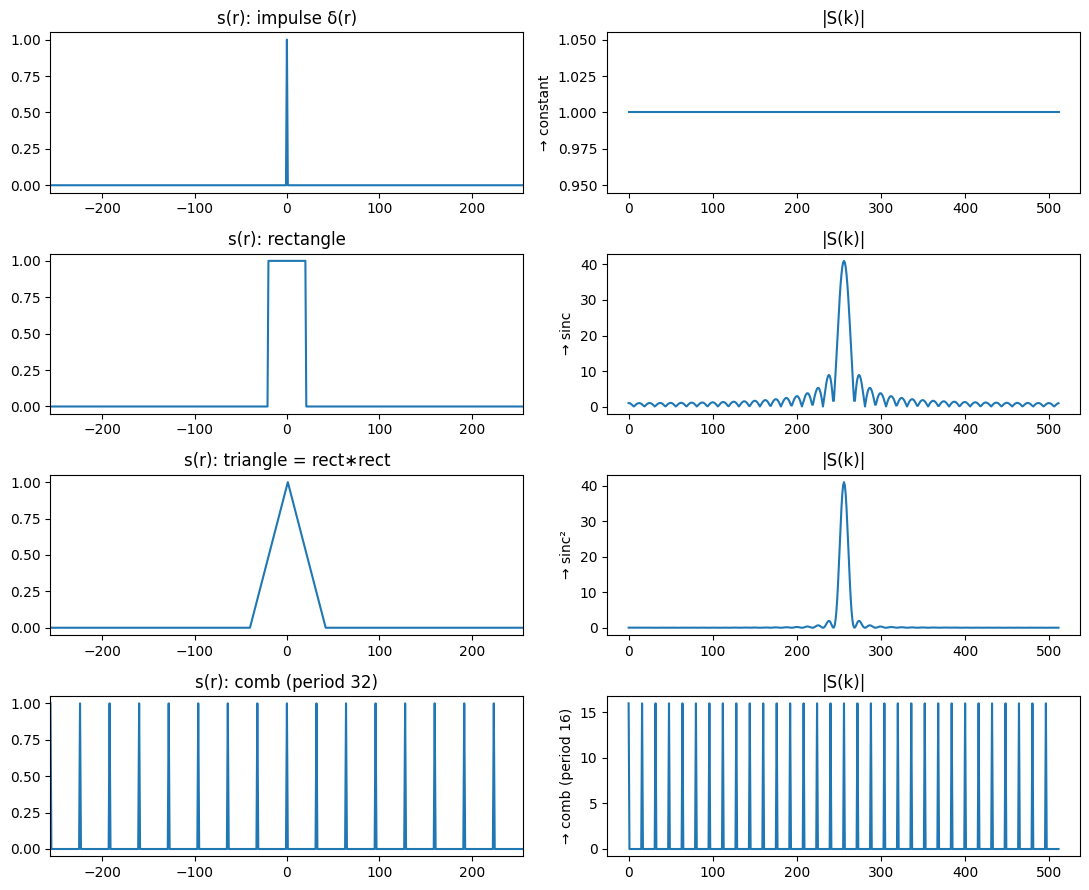

Note: comb of period T=32 -> comb of period N/T = 16. Sampling replicates the spectrum.


In [12]:
N = 512
r = np.arange(N) - N//2

impulse = np.zeros(N); impulse[N//2] = 1.0
rect    = (np.abs(r) <= 20).astype(float)
triangle = np.convolve(rect, rect, mode='same'); triangle /= triangle.max()
comb    = np.zeros(N); comb[::32] = 1.0

def ft1d(x):
    return np.fft.fftshift(np.abs(np.fft.fft(np.fft.ifftshift(x))))

fig, ax = plt.subplots(4, 2, figsize=(11, 9))
for i, (x, name) in enumerate([(impulse,"impulse δ(r)"),(rect,"rectangle"),
                                (triangle,"triangle = rect∗rect"),(comb,"comb (period 32)")]):
    ax[i,0].plot(r, x); ax[i,0].set_title(f"s(r): {name}"); ax[i,0].set_xlim(-N//2, N//2)
    ax[i,1].plot(ft1d(x)); ax[i,1].set_title(f"|S(k)|")
ax[0,1].set_ylabel("→ constant"); ax[1,1].set_ylabel("→ sinc")
ax[2,1].set_ylabel("→ sinc²");    ax[3,1].set_ylabel("→ comb (period 16)")
plt.tight_layout(); plt.show()
print("Note: comb of period T=32 -> comb of period N/T = 16. Sampling replicates the spectrum.")

## 3. 2D Fourier transform and k-space

The MR signal **is** the 2D FT of the image. We use a synthetic Shepp–Logan phantom — its
hard edges are perfect for the Gibbs-ringing demos later.

The *fftshift dance* (`ifft2c`) reconstructs centered k-space correctly. Skipping the shifts
splits the image into the four corners — we show that failure mode too.

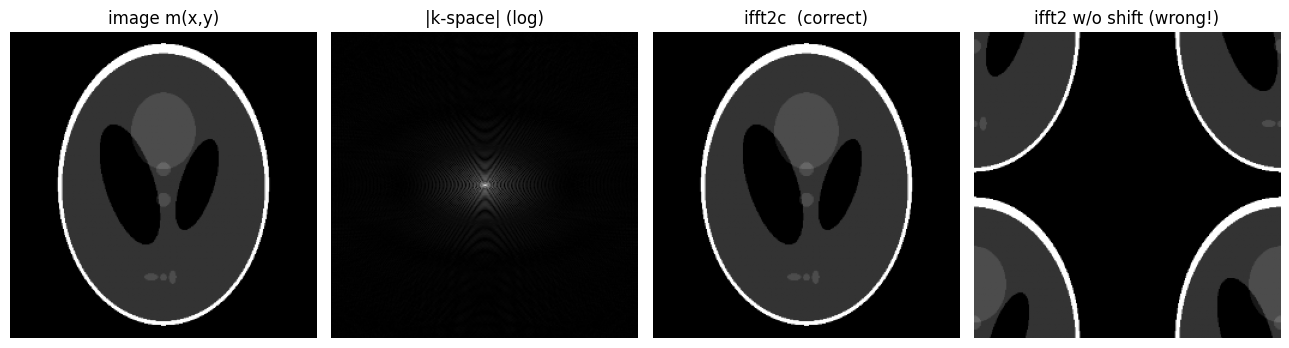

Reconstruction error (correct): 3.0743015864392845e-16


In [13]:
N = 256
phantom = resize(shepp_logan_phantom(), (N, N), anti_aliasing=True)

ksp = fft2c(phantom)                 # the 'measured' k-space
recon = ifft2c(ksp)                  # correct reconstruction

# WRONG way: ifft2 directly on centered data (no shifts) -> quadrant swap
wrong = np.abs(np.fft.ifft2(ksp))

fig, ax = plt.subplots(1, 4, figsize=(13, 3.5))
ax[0].imshow(phantom);            ax[0].set_title("image m(x,y)")
ax[1].imshow(kshow(ksp));         ax[1].set_title("|k-space| (log)")
ax[2].imshow(np.abs(recon));      ax[2].set_title("ifft2c  (correct)")
ax[3].imshow(wrong);              ax[3].set_title("ifft2 w/o shift (wrong!)")
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()
print("Reconstruction error (correct):", np.linalg.norm(np.abs(recon)-phantom)/np.linalg.norm(phantom))

## 4. Low vs high spatial frequencies

- **Center of k-space (low freq):** bulk shape, brightness, **contrast**.
- **Periphery (high freq):** **edges** and fine detail.

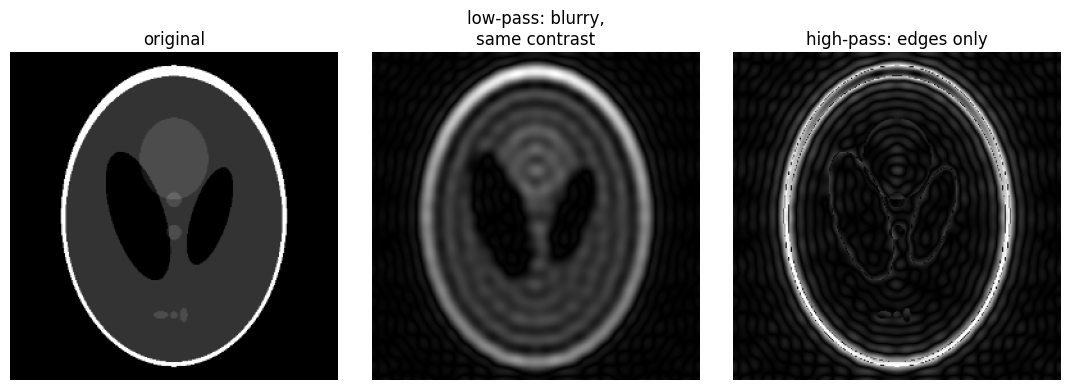

In [14]:
def disk_mask(N, radius):
    yy, xx = np.ogrid[:N, :N]
    return ((xx - N//2)**2 + (yy - N//2)**2) <= radius**2

low_mask  = disk_mask(N, 18)          # keep only the center
high_mask = ~disk_mask(N, 18)         # remove the center

low_img  = np.abs(ifft2c(ksp * low_mask))
high_img = np.abs(ifft2c(ksp * high_mask))

fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
ax[0].imshow(phantom);  ax[0].set_title("original")
ax[1].imshow(low_img);  ax[1].set_title("low-pass: blurry,\nsame contrast")
ax[2].imshow(high_img, vmax=np.percentile(high_img, 99.5))
ax[2].set_title("high-pass: edges only")
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 5. k-space cropping → resolution (the 64/128/256 demo)

Keeping a smaller central square of k-space throws away high frequencies → **lower resolution
(blurrier)** — but the **contrast is unchanged**. `k_max` sets resolution.

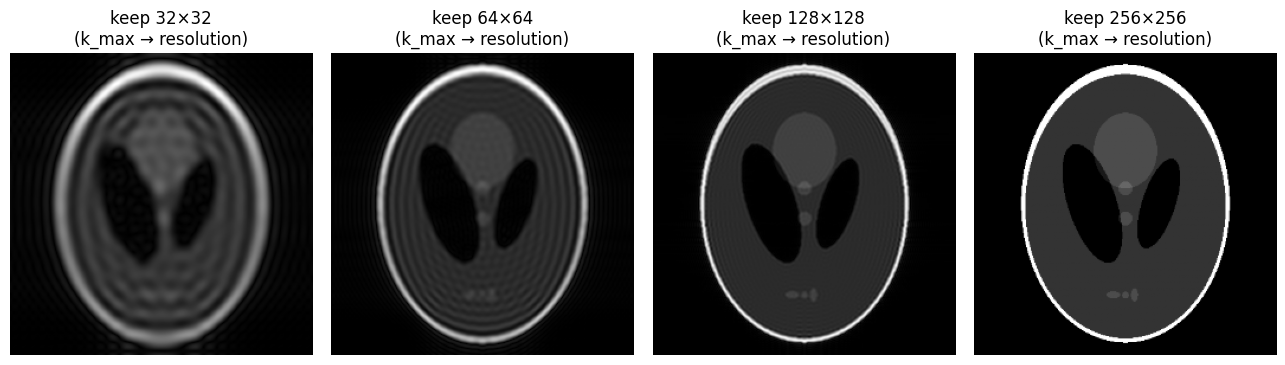

Smaller central box = lower k_max = lower resolution. Brightness/contrast preserved.


In [15]:
sizes = [32, 64, 128, 256]
fig, ax = plt.subplots(1, len(sizes), figsize=(13, 3.5))
for i, s in enumerate(sizes):
    mask = np.zeros((N, N))
    c = N//2; h = s//2
    mask[c-h:c+h, c-h:c+h] = 1                 # central s×s box
    img = np.abs(ifft2c(ksp * mask))
    ax[i].imshow(img); ax[i].set_title(f"keep {s}×{s}\n(k_max → resolution)")
    ax[i].axis('off')
plt.tight_layout(); plt.show()
print("Smaller central box = lower k_max = lower resolution. Brightness/contrast preserved.")

## 6. Sampling & aliasing (Nyquist)

Cartesian Nyquist spacing: `Δk = 1/W` (W = FOV). Undersampling (Δk too large) shrinks the
FOV below the object → **wrap-around / fold-over aliasing**. Here we keep every 2nd k-space
row (`Δk_y → 2·Δk_y`).

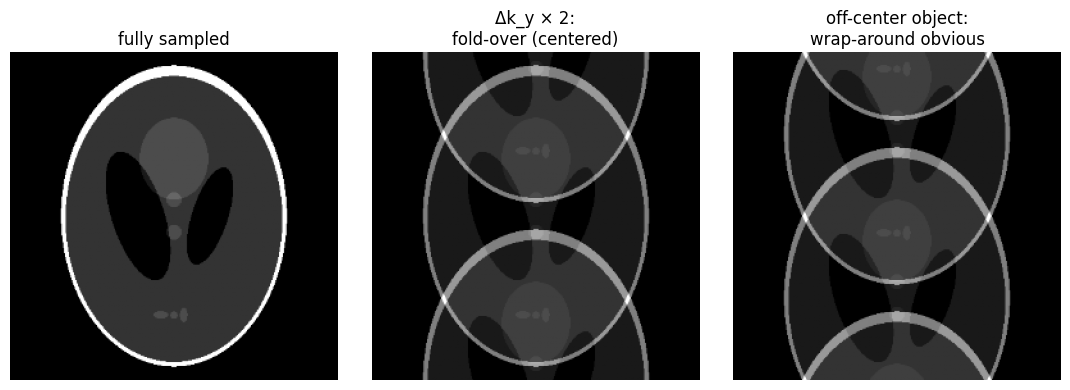

Halving the sampling density halves the FOV -> the object folds onto itself.


In [16]:
under = np.zeros_like(ksp)
under[::2, :] = ksp[::2, :]          # keep every other phase-encode line
alias_img = np.abs(ifft2c(under))

# Make the wrap-over obvious: a phantom shifted off-center
shifted = np.roll(phantom, N//4, axis=0)
ksp_sh  = fft2c(shifted)
und_sh  = np.zeros_like(ksp_sh); und_sh[::2,:] = ksp_sh[::2,:]
alias_sh = np.abs(ifft2c(und_sh))

fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
ax[0].imshow(phantom);   ax[0].set_title("fully sampled")
ax[1].imshow(alias_img); ax[1].set_title("Δk_y × 2:\nfold-over (centered)")
ax[2].imshow(alias_sh);  ax[2].set_title("off-center object:\nwrap-around obvious")
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()
print("Halving the sampling density halves the FOV -> the object folds onto itself.")

## 7a. Exercise 1 — reconstruct k-space, and *why we shift*

In the exercise sheet you load `kdata1` (data already in k-space). Here we synthesize an
equivalent centered k-space so the notebook is self-contained.

The largest coefficients sit at the **center** (zero/low frequency). `np.fft.ifft2` expects the
origin at index 0, so we **`ifftshift` → transform → `fftshift` back to center**, divide by the
size for normalization, and take the **magnitude** (radiologists view |image|).

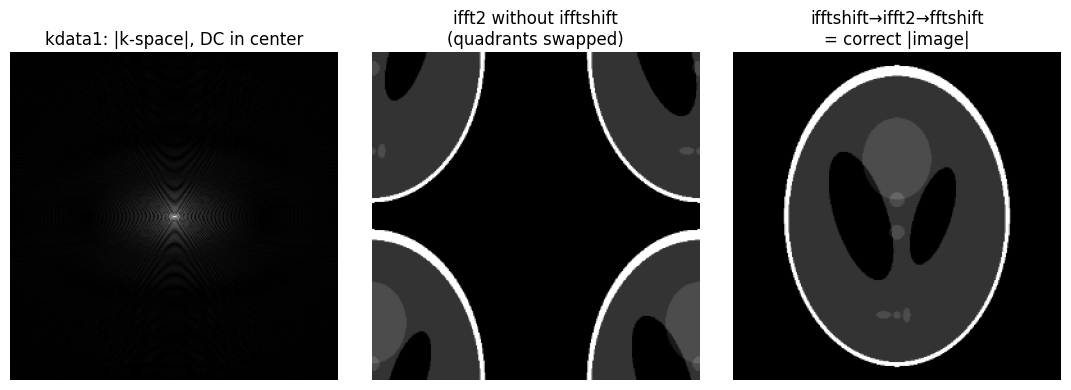

In [17]:
kdata1 = fft2c(phantom)              # 'provided' k-space

# Step through the pipeline explicitly
step_shift = np.fft.ifftshift(kdata1)     # center -> corner (origin at index 0)
step_tf    = np.fft.ifft2(step_shift)     # inverse transform
step_back  = np.fft.fftshift(step_tf)     # origin -> center for display
recon_mag  = np.abs(step_back) * np.sqrt(kdata1.size)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
ax[0].imshow(kshow(kdata1));            ax[0].set_title("kdata1: |k-space|, DC in center")
ax[1].imshow(np.abs(np.fft.ifft2(kdata1)));  ax[1].set_title("ifft2 without ifftshift\n(quadrants swapped)")
ax[2].imshow(recon_mag);                ax[2].set_title("ifftshift→ifft2→fftshift\n= correct |image|")
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 7b. Exercise 2 — the Point Spread Function (PSF)

The **PSF is the image of a single point** = the inverse FT of the k-space window.
`image = object ∗ PSF`. Narrow PSF → sharp; wide PSF → blurry.
Boxcar (truncation) → **sinc PSF** with big side lobes (ringing). Hamming → broad, low-side-lobe PSF.

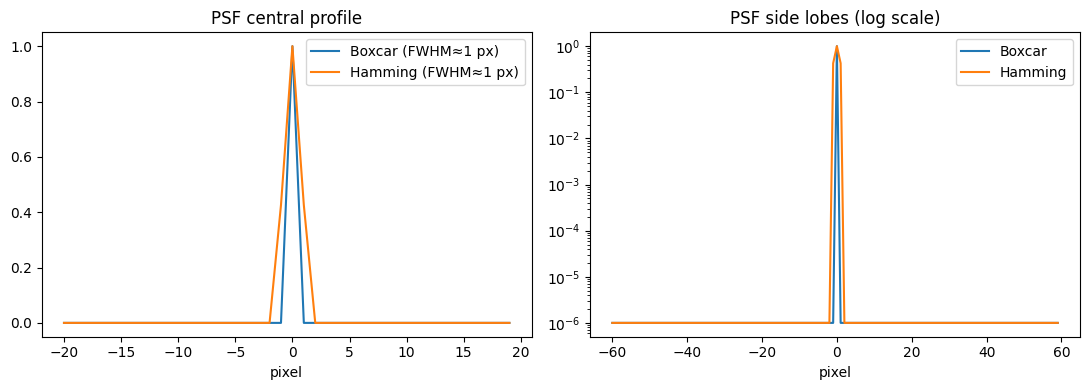

Boxcar: narrow main lobe (sharp) but large side lobes -> ringing.
Hamming: wider main lobe (blurrier) but tiny side lobes -> ringing suppressed.


In [18]:
def hamming2d(N):
    w = 0.54 + 0.46*np.cos(2*np.pi*(np.arange(N)-N//2)/N)
    return np.outer(w, w)

boxcar  = np.ones((N, N))
hamming = hamming2d(N)

# PSF = image of a point source = ifft of the window (a point in k-space is 'constant',
# so windowing k-space and inverse-transforming gives the PSF directly).
psf_box = np.abs(ifft2c(boxcar))
psf_ham = np.abs(ifft2c(hamming))

# 1D central profiles (zoomed) + FWHM
def fwhm(profile):
    p = profile / profile.max()
    above = np.where(p >= 0.5)[0]
    return above[-1] - above[0] + 1
cx = N//2
prof_box = psf_box[cx]; prof_ham = psf_ham[cx]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
zoom = slice(cx-20, cx+20)
ax[0].plot(np.arange(-20,20), prof_box[zoom]/prof_box.max(), label=f"Boxcar (FWHM≈{fwhm(prof_box)} px)")
ax[0].plot(np.arange(-20,20), prof_ham[zoom]/prof_ham.max(), label=f"Hamming (FWHM≈{fwhm(prof_ham)} px)")
ax[0].set_title("PSF central profile"); ax[0].legend(); ax[0].set_xlabel("pixel")
ax[1].semilogy(np.arange(-60,60), prof_box[cx-60:cx+60]/prof_box.max()+1e-6, label="Boxcar")
ax[1].semilogy(np.arange(-60,60), prof_ham[cx-60:cx+60]/prof_ham.max()+1e-6, label="Hamming")
ax[1].set_title("PSF side lobes (log scale)"); ax[1].legend(); ax[1].set_xlabel("pixel")
plt.tight_layout(); plt.show()
print("Boxcar: narrow main lobe (sharp) but large side lobes -> ringing.")
print("Hamming: wider main lobe (blurrier) but tiny side lobes -> ringing suppressed.")

## 7c. Exercise 3 — Hamming vs rectangle filtering & Gibbs ringing

Truncating k-space (rectangle) rings near sharp edges. A Hamming window suppresses the ringing
at the cost of resolution. We crop to a modest matrix so Gibbs is visible, then compare.

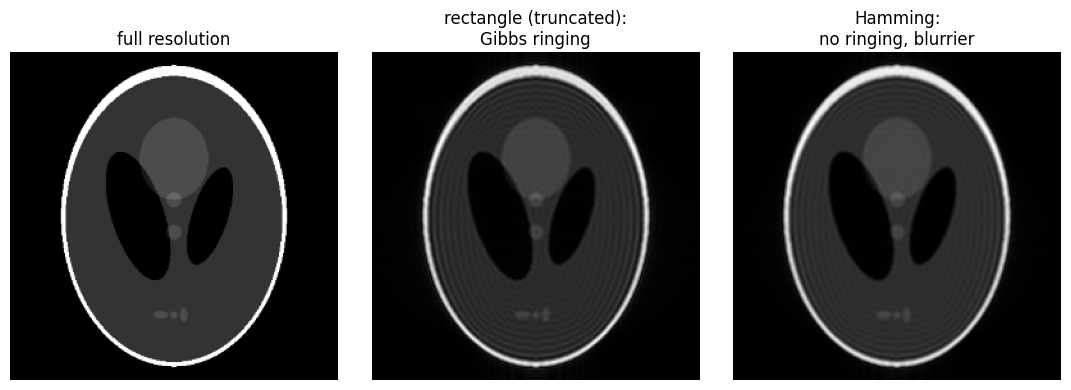

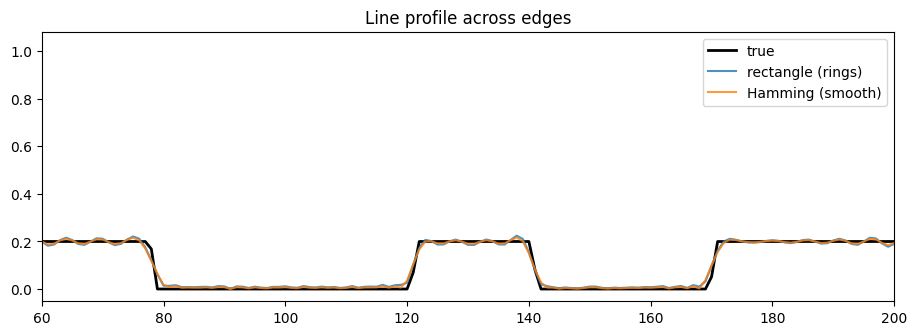

Rectangle overshoots/oscillates at each edge (Gibbs). Hamming is smooth but rounded.


In [19]:
crop = 96                                   # truncate k-space -> guarantees Gibbs
c = N//2; h = crop//2
box_win = np.zeros((N, N)); box_win[c-h:c+h, c-h:c+h] = 1
ham_full = hamming2d(N)
ham_win = box_win * ham_full                 # Hamming taper inside the same support

rect_img = np.abs(ifft2c(ksp * box_win))
ham_img  = np.abs(ifft2c(ksp * ham_win))

fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
ax[0].imshow(phantom);  ax[0].set_title("full resolution")
ax[1].imshow(rect_img); ax[1].set_title("rectangle (truncated):\nGibbs ringing")
ax[2].imshow(ham_img);  ax[2].set_title("Hamming:\nno ringing, blurrier")
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

# Line profile across a sharp edge shows the ringing directly
row = N//2
plt.figure(figsize=(11,3.5))
plt.plot(phantom[row],  label="true", lw=2, color='k')
plt.plot(rect_img[row], label="rectangle (rings)", alpha=0.8)
plt.plot(ham_img[row],  label="Hamming (smooth)", alpha=0.8)
plt.xlim(60, 200); plt.title("Line profile across edges"); plt.legend(); plt.show()
print("Rectangle overshoots/oscillates at each edge (Gibbs). Hamming is smooth but rounded.")

## 7d. Exercise 5 — Oversampling in the readout direction

Oversampling (smaller Δk / more samples per readout) enlarges the readout FOV → prevents
fold-over, and adds samples → **smaller PSF side lobes** → less ringing.
The image you want = the **central part of the oversampled image** (decimate/crop back).

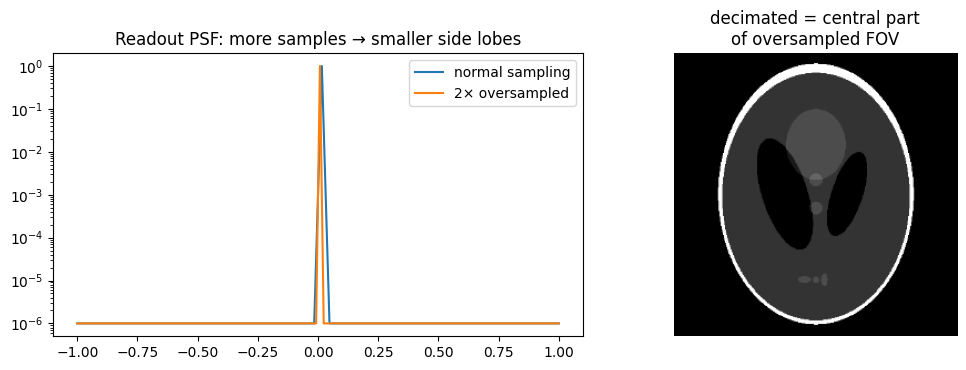

In [20]:
# Compare a 1D readout PSF at normal vs 2x oversampling (more samples = lower side lobes)
def readout_psf(n_samples, oversample):
    k = np.ones(n_samples*oversample)            # boxcar of given length
    psf = np.abs(np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(k))))
    return psf/psf.max()

p1 = readout_psf(64, 1)
p2 = readout_psf(64, 2)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].semilogy(np.linspace(-1,1,len(p1)), p1+1e-6, label="normal sampling")
ax[0].semilogy(np.linspace(-1,1,len(p2)), p2+1e-6, label="2× oversampled")
ax[0].set_title("Readout PSF: more samples → smaller side lobes"); ax[0].legend()

# 'decimated image = central part of oversampled image'
big_fov = np.zeros((N, 2*N)); big_fov[:, N//2:N//2+N] = phantom   # object in a 2× readout FOV
ksp_big = fft2c(big_fov)
recon_big = np.abs(ifft2c(ksp_big))
decimated = recon_big[:, N//2:N//2+N]
ax[1].imshow(decimated); ax[1].set_title("decimated = central part\nof oversampled FOV"); ax[1].axis('off')
plt.tight_layout(); plt.show()

## 8. Zero-padding = Fourier interpolation

Padding k-space with zeros shrinks the **pixel size** but adds **no** high-frequency data →
**no real resolution gain**. It's a smooth (sinc) interpolation, and it makes Gibbs ringing
more visible.

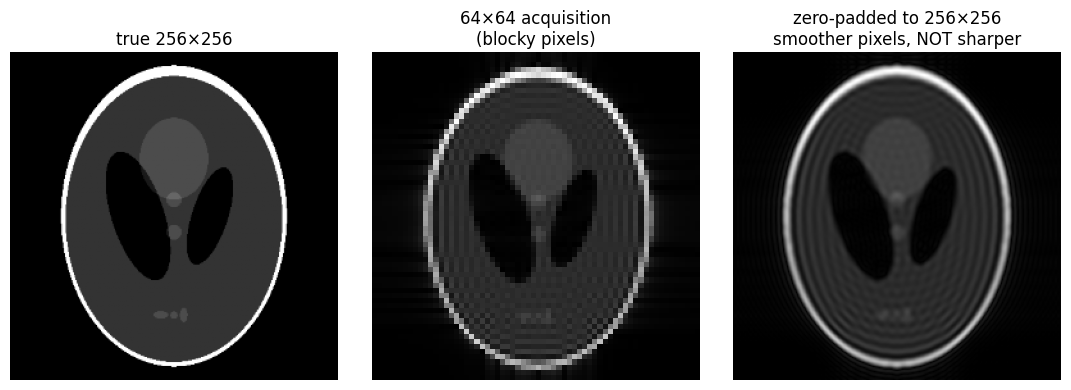

Same information as 64×64 -> same resolution. Zero-padding only interpolates + reveals ringing.


In [21]:
small = 64
c = N//2; h = small//2
ksp_small = ksp[c-h:c+h, c-h:c+h]            # a genuinely low-res acquisition (64×64)
img_small = np.abs(ifft2c(ksp_small))        # displayed at 64×64

pad = np.zeros((N, N), dtype=complex)         # zero-pad back to 256×256
pad[c-h:c+h, c-h:c+h] = ksp_small
img_padded = np.abs(ifft2c(pad))              # displayed at 256×256, same true resolution

fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
ax[0].imshow(phantom);     ax[0].set_title("true 256×256")
ax[1].imshow(img_small);   ax[1].set_title("64×64 acquisition\n(blocky pixels)")
ax[2].imshow(img_padded);  ax[2].set_title("zero-padded to 256×256\nsmoother pixels, NOT sharper")
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()
print("Same information as 64×64 -> same resolution. Zero-padding only interpolates + reveals ringing.")

## 9. SNR ∝ V·√T

Smaller voxels (higher resolution) → less signal per voxel → lower SNR. Averaging longer (√T)
buys SNR back. We add complex Gaussian noise to k-space and measure
`SNR = mean(signal) / std(background)`.

Small voxel (256×256):  SNR ≈ 2.0
Larger voxel (2×2 bin): SNR ≈ 4.0   (~2× higher: bigger V → more signal/voxel)


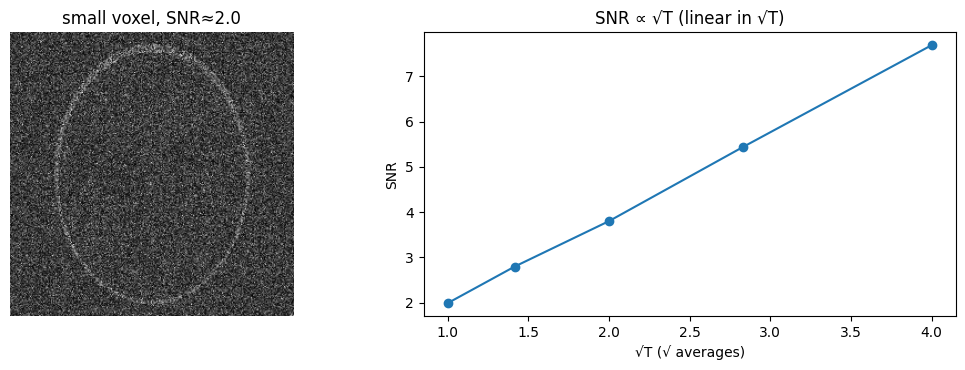

In [22]:
def add_noise(ksp, sigma):
    n = sigma*(np.random.randn(*ksp.shape) + 1j*np.random.randn(*ksp.shape))
    return ksp + n

sigma = 0.6
img_hi = np.abs(ifft2c(add_noise(ksp, sigma)))        # full-resolution = small voxel

# A larger voxel = averaging neighbouring pixels. Signal is preserved; independent noise
# averages down -> higher SNR. This is the V part of SNR ∝ V·√T (here in 2D).
def bin2x2(img):
    return img.reshape(img.shape[0]//2, 2, img.shape[1]//2, 2).mean(axis=(1, 3))
img_lo = bin2x2(img_hi)                                # 2× larger voxel (128×128)

def snr(img, sig_box, bg_box):
    (r0,r1,c0,c1) = sig_box; (b0,b1,d0,d1) = bg_box
    return img[r0:r1, c0:c1].mean() / img[b0:b1, d0:d1].std()

snr_hi = snr(img_hi, (110,150,110,150), (0,30,0,30))   # 256×256 grid
snr_lo = snr(img_lo, (55,75,55,75),     (0,15,0,15))   # 128×128 grid
print(f"Small voxel (256×256):  SNR ≈ {snr_hi:.1f}")
print(f"Larger voxel (2×2 bin): SNR ≈ {snr_lo:.1f}   (~2× higher: bigger V → more signal/voxel)")

# Averaging T acquisitions: SNR grows like sqrt(T)
Ts = [1, 2, 4, 8, 16]
snrs = []
for Tn in Ts:
    avg = np.mean([np.abs(ifft2c(add_noise(ksp, sigma))) for _ in range(Tn)], axis=0)
    snrs.append(snr(avg, (110,150,110,150), (0,30,0,30)))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].imshow(img_hi); ax[0].set_title(f"small voxel, SNR≈{snr_hi:.1f}"); ax[0].axis('off')
ax[1].plot(np.sqrt(Ts), snrs, 'o-'); ax[1].set_xlabel("√T (√ averages)")
ax[1].set_ylabel("SNR"); ax[1].set_title("SNR ∝ √T (linear in √T)")
plt.tight_layout(); plt.show()

## Wrap-up

You've now built the whole Cartesian reconstruction pipeline from synthetic data: the signal is
the FT of the image, you reconstruct with the fftshift dance, `Δk` sets FOV and `k_max` sets
resolution, undersampling aliases, truncation rings (Gibbs), windowing trades resolution for
smoothness, zero-padding interpolates without adding resolution, and SNR ∝ V·√T.

**Now break it:** change `N`, the crop size, the window (try a Gaussian or Tukey), the
undersampling factor (try `[::3]`), or the noise `sigma`, and re-run. Then try the 10 self-test
questions in `CMRI_L02_summary.md` without peeking.